In [1]:
%pip install -q -U transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 12.7 MB/s eta 0:00:00


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model and tokenizer
MODEL_NAME = "textattack/bert-base-uncased-SST-2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()
print("Device:", device)

config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Device: cpu


In [3]:
dataset = load_dataset("nyu-mll/glue", "sst2", split="validation")
sample = dataset.shuffle(seed=SEED).select(range(min(500, len(dataset))))
display(pd.DataFrame(sample[:5]))

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

sst2/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sst2/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

sst2/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

sst2/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

,sentence,label,idx
0,it gets onto the screen just about as much of ...,1,726
1,my big fat greek wedding uses stereotypes in a...,1,737
2,"for the most part , director anne-sophie birot...",1,51
3,cq 's reflection of artists and the love of ci...,1,482
4,charles ' entertaining film chronicles seinfel...,1,426


In [4]:
@torch.no_grad()
def predict_texts(texts, batch_size=32):
    predictions, positive_probabilities = [], []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(
            batch, padding=True, truncation=True, max_length=128, return_tensors="pt"
        ).to(device)
        probabilities = model(**encoded).logits.softmax(dim=-1)
        predictions.extend(probabilities.argmax(dim=-1).cpu().tolist())
        positive_probabilities.extend(probabilities[:, 1].cpu().tolist())
    return np.array(predictions), np.array(positive_probabilities)

In [5]:
texts = sample["sentence"]
y_true = np.array(sample["label"])
y_pred, positive_probability = predict_texts(texts)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="binary", zero_division=0
)
print(pd.Series({"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}).round(3))

accuracy     0.918
precision    0.923
recall       0.920
f1           0.921
dtype: float64


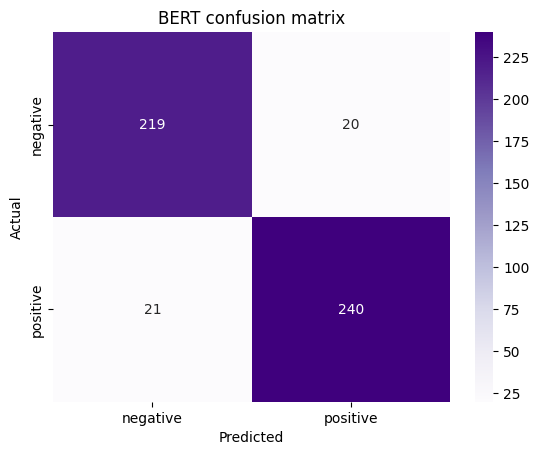

In [6]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Purples",
    xticklabels=["negative", "positive"], yticklabels=["negative", "positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT confusion matrix")
plt.show()

In [7]:
review = pd.DataFrame({
    "text": texts,
    "actual": y_true,
    "predicted": y_pred,
    "positive_probability": positive_probability,
})
mistakes = review[review.actual != review.predicted].copy()
mistakes["confidence"] = np.where(
    mistakes.predicted == 1, mistakes.positive_probability,
    1 - mistakes.positive_probability,
)
display(mistakes.sort_values("confidence", ascending=False).head(10))

,text,actual,predicted,positive_probability,confidence
282,"the lower your expectations , the more you 'll...",0,1,0.999311,0.999311
184,it 's everything you do n't go to the movies f...,0,1,0.999016,0.999016
278,as unseemly as its title suggests .,1,0,0.001850,0.998150
460,while there 's something intrinsically funny a...,1,0,0.002102,0.997898
366,although huppert 's intensity and focus has a ...,0,1,0.997003,0.997003
327,"movie fans , get ready to take off ... the oth...",0,1,0.996455,0.996455
481,every nanosecond of the the new guy reminds yo...,0,1,0.996436,0.996436
183,"you wo n't like roger , but you will quickly r...",0,1,0.995712,0.995712
324,harrison 's flowers puts its heart in the righ...,1,0,0.004314,0.995686
244,reign of fire looks as if it was made without ...,1,0,0.004459,0.995541


In [8]:
custom_text = ["The story was slow, but the ending was wonderful."]
label, probability = predict_texts(custom_text)
print(custom_text[0], "->", ["negative", "positive"][label[0]], f"(positive probability={probability[0]:.3f})")

The story was slow, but the ending was wonderful. -> positive (positive probability=0.999)
